In [1]:
import yfinance as yf
import pandas as pd

# Скачиваем данные по природному газу (тикер NG=F)
# Мы берем данные за последние 5 лет
data = yf.download('NG=F', period='5y', interval='1d')

# Сохраняем в CSV, чтобы у тебя был файл для проекта
data.to_csv('gas_prices.csv')

# Выводим первые строки, чтобы убедиться, что всё скачалось
print(data.head())


[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open  Volume
Ticker       NG=F   NG=F   NG=F   NG=F    NG=F
Date                                          
2021-04-27  2.873  2.876  2.783  2.786   41283
2021-04-28  2.925  2.936  2.868  2.873  131127
2021-04-29  2.911  2.971  2.883  2.951  123113
2021-04-30  2.931  2.962  2.891  2.906  101566
2021-05-03  2.966  2.975  2.900  2.938  101038


Matplotlib is building the font cache; this may take a moment.


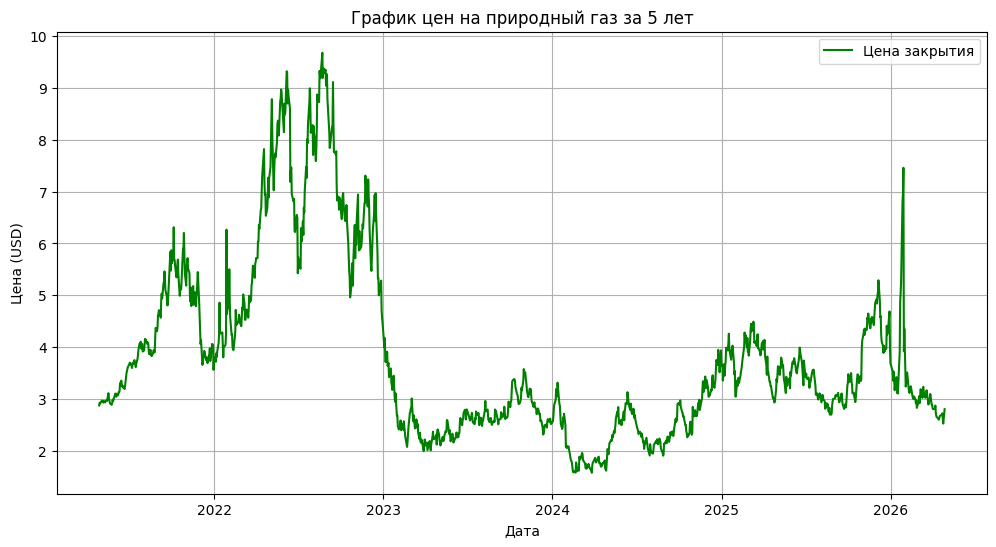

In [2]:
import matplotlib.pyplot as plt

# Мы используем данные из переменной 'data', которую скачали выше
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], color='green', label='Цена закрытия')
plt.title('График цен на природный газ за 5 лет')
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Создаем новую таблицу, где будет только цена закрытия
df_final = data[['Close']].copy()

# Создаем "признак": цена вчера (сдвигаем данные на 1 день)
df_final['Yesterday_Price'] = df_final['Close'].shift(1)

# Удаляем пустые строки, которые появились из-за сдвига
df_final.dropna(inplace=True)

print(df_final.head())

Price       Close Yesterday_Price
Ticker       NG=F                
Date                             
2021-04-28  2.925           2.873
2021-04-29  2.911           2.925
2021-04-30  2.931           2.911
2021-05-03  2.966           2.931
2021-05-04  2.967           2.966


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Готовим данные
X = df_final[['Yesterday_Price']] # Вход: цена вчера
y = df_final['Close']            # Выход: цена сегодня (цель)

# Разделяем данные: 80% для обучения, 20% для проверки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 2. Создаем и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Делаем прогноз на тестовых данных
predictions = model.predict(X_test)

print("Модель обучена!")

Модель обучена!


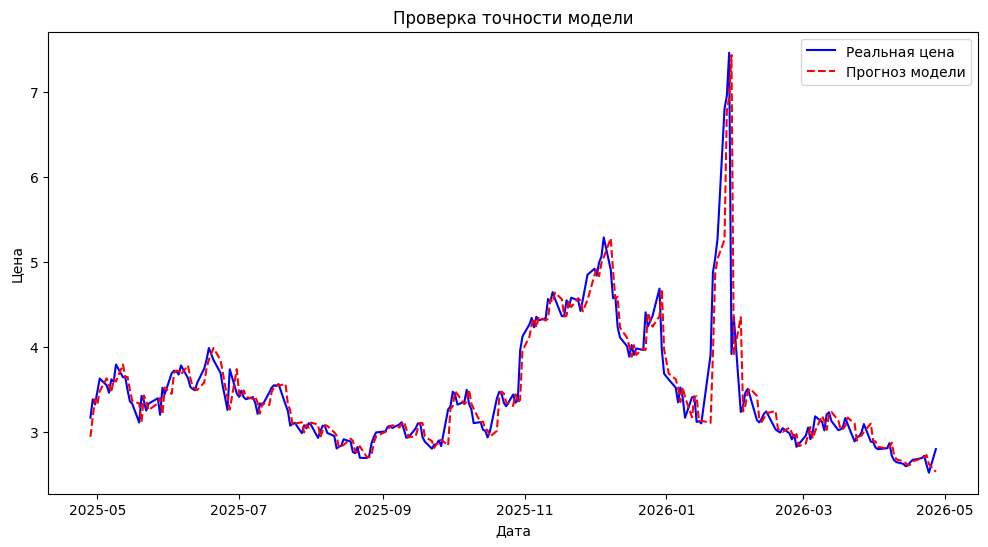

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Реальная цена', color='blue')
plt.plot(y_test.index, predictions, label='Прогноз модели', color='red', linestyle='--')
plt.title('Проверка точности модели')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.show()
plt.savefig('prediction_plot.png')

In [10]:
# 1. Берем последнюю цену
last_price_raw = df_final['Close'].iloc[-1]
last_price_value = last_price_raw.item() 

# 2. Делаем прогноз
next_day_prediction = model.predict([[last_price_value]])

# 3. Выводим результат (добавили [0] к прогнозу)
print(f"Последняя цена сегодня: {last_price_value:.2f}$")
print(f"Прогноз цены на завтра: {next_day_prediction[0][0]:.2f}$")

Последняя цена сегодня: 2.80$
Прогноз цены на завтра: 2.81$
